# Trabajo Práctico de Laboratorio 1 <img src="fig/logo_utn_encabezado.png" width="250" align="right"/>
## Teoría de los Circuitos II
### Docentes: Mariano Llamedo Soria, David Moharos, César Fuoco
### por Julián Galeano Pinazo


En este trabajo práctico, se diseñó y armó un filtro activo para realizarle mediciones de transferencia de módulo y fase con un osciloscopio y un analizador de audio. Estas mediciones se compararon con los resultados de simulaciones de este filtro.

#### Objetivos

1. Diseñar, implementar y armar un filtro analógico activo real.
2. Medir las características de la transferencia del filtro con distintos instrumentos.
3. Determinar las diferencias entre el modelo ideal del filtro, el real simulado y el real medido. 

#### Diseño

El filtro requerido para este trabajo era un pasa-banda de las siguientes características:

* Funcion de aproximación: Chevyshev
* Frecuencia Central = 6 kHz
* Q = 3 $\Rightarrow$ Ancho de banda = 2 kHz
* Atenuación máxima en banda de paso = 2.5 dB
* Frecuencias de rechazo = 600 Hz, 60 kHz
* Atenuación mínima en banda de rechazo = 15 dB

Para diseñar el filtro, partimos de un prototipo pasa-bajos mediante aproximación de Chevyshev:


$$
\epsilon^2 = 10^{\dfrac{\alpha_{max}}{10}} = 0,778
$$

Normalizado en funcion de $\omega_0$, $\omega_s = 0.1\;ó\;10$, mapeado al dominio de frecuencia del prototipo, es:

$$
\omega_{s,LP} = Q\dfrac{\omega_{s,BP}^2-1}{\omega_{s,BP}} = 29.7
$$

$$
\Rightarrow \left. \alpha_s \right|_{n=1} = 10 \cdot log_{10}(1+\epsilon^2cosh^2(1\cdot cosh^{-1}(\omega_s))) = 28,37 > \alpha_{min}
$$

Como el prototipo es de orden 1, el pasabanda resultante será de orden 2:

$$
\left. T(s) \right|_{s=Q\frac{s^2+1}{s}} = \dfrac{1}{s+\epsilon^{-1}} = \dfrac{1}{Q\frac{s^2+1}{s}+1.133}
$$

$$
T(s) = \dfrac{s}{Qs^2 + 1.133s + Q} =  \dfrac{s\frac{1}{Q}}{s^2 + \frac{1.133}{Q}s + 1} = \dfrac{s\frac{1}{3}}{s^2 + \frac{1.133}{Q}s + 1} 
$$
$$
T(s) = \dfrac{s\frac{1}{3}}{s^2+s\frac{1}{2.646}+1} \Rightarrow \dfrac{s\frac{1}{2.646}}{s^2+s\frac{1}{2.646}+1}, \; Q=2.646
$$

Se eligió una topología Multiple Feedback para implementarlo:

<figure style="float: left; margin-right: 10px;">
    <img src="fig/mfb_bp.png"  width="450"/>
    <figcaption align="center"><b>Figura 1:</b> Topología MFB utilizada.</figcaption>
</figure>

$$
\begin{cases}
V_a \left[ G_1+G_2+s(C_1+C_2) \right] -V_i(G_1) - V_o(sC_1) = 0 \\
-V_a(sC_2)-V_o (G_3) = 0 \Rightarrow V_a=-V_o\dfrac{G_3}{sC_2}
\end{cases}
$$
$$
V_o \dfrac{G_3 [G_1 + G_2 + s(C_1+C_2)] + s^2 C_1 C_2}{s C_2} = -G_1 V_i
$$
$$
V_o \dfrac{s^2 + s G_3 \frac{C_1+C_2}{C_1C_2} + \frac{G_1+G_2}{C_1C_2}}{s\frac{1}{C_1}} = -G_1 V_i
$$

$$
\frac{V_o}{V_i} = T(s) = -\frac{G_1C_2}{G_3(C_1+C_2)} \dfrac{sG_3\frac{C_1+C_2}{C_1C_2}}{s^2 + s G_3 \frac{C_1+C_2}{C_1C_2} + \frac{G_1+G_2}{C_1C_2}}
$$

Para $C_1=C_2=C$, $R_1=R_2=R$ y $R_3=1$, si parametrizamos en funcion de $Q$ y $\omega_0$ queda:

$$
\begin{cases}
\omega_0^2=\dfrac{2G}{C^2} \\
\dfrac{\omega_0}{Q} = \dfrac{2}{C} \\
K = -\frac{G\cdot C}{1\cdot 2C}
\end{cases}
\Rightarrow
\begin{cases}
C = \dfrac{2Q}{\omega_0} \\
G = 2Q^2 \Rightarrow R = \dfrac{1}{2Q^2} \\
K = -\frac{2Q^2\frac{2Q}{\omega_0}}{1\cdot 2\frac{2Q}{\omega_0}} = -Q^2
\end{cases}$$

Para $f_0 = 6000 \text{ Hz}$ y $\Omega_Z = 1$:

$$
C=\frac{2\cdot 2.646}{2\pi \cdot 6000\text{ Hz}} = 140.37\; \mu F
$$

$$
R=\frac{1}{2\cdot 2.646^2} = 71.42\; m\Omega
$$

y con una $\Omega_Z = 14000\; \Omega$:

$$ C=\frac{140.37\; \mu F}{14000} = 10.03\; nF, \quad R = 71.42\; m\Omega \cdot 14000 = 999.8\; \Omega, \quad R_3=14\; k\Omega$$

Lo cual esta dentro de los valores comerciales de capacitores y resistores.

#### Armado del circuito

A la hora de probar circuitos, una de las mayores diferencias que se encuentran entre las simulaciones y las mediciones reales es la tolerancia de los componentes.

Los resistores más habituales estan en el 5% de tolerancia, aunque conseguirlos de precisión al 1% no es tan complicado. Los capacitores mas básicos tienen 20% de tolerancia, y conseguir capacitores por debajo del 5% es muy costoso. Ademas, para corregir los valores de resistencia existe una variedad de potenciometros de gran precisión, muy sencillos de incluir en circuios impresos debido a su tamaño, cosa que en capacitores no es tan sencilla de lograr. Por esta razón, se eligió diseñar el circuito con un trimpot de corrección acompañando cada resistor.

Se eligieron los potenciomentros de ajuste [3926W](datasheets/3296W.pdf) de Bourns, y como amplificador operacional se eligió el [NE5534](datasheets/NE5534.pdf) de Texas Instruments. Se incluyeron pares de pines puenteados de 1cm de largo en la entrada y salida del filtro, asi como en las entradas de alimentación, para facilitar la conexión de la placa, dando un total de 7 pares de pines: 2 para la señal de entrada, 2 para la de salida y 3 para la alimentación.

Por un error con la compra de componentes, se terminó armando el circuito con una $\Omega_Z=1400\; \Omega$, $C=100\; nF$, $R=100\; \Omega$, lo que da una impedancia de entrada del circuito muy cercana a la de salida del generador de señales que fue utilizado ($50\; \Omega$). En las conclusiones se evaluará la influencia que puede haber tenido este problema.

A continuación los diagramas y una foto del circuito armado:

<figure>
    <img src="fig/sch.png" width="700"/>
    <figcaption align="center"><b>Figura 2:</b> Diagrama esquemático del circuito.</figcaption>
</figure>

<figure>
    <img src="fig/pcb.png" width="700"/>
    <figcaption align="center"><b>Figura 3:</b> Diseño del PCB.</figcaption>
</figure>

<figure>
    <img src="fig/circuito_armado.jpeg" width="700"/>
    <figcaption align="center"><b>Figura 4:</b> Circuito armado.</figcaption>
</figure>


#### Resultados

##### Mediciones

Se midió, para tener registro, los valores de los resistores y capacitores a la hora de realizar las pruebas, con los siguientes resultados:

$
R1 = 101\Omega ,\; R2= 101\Omega ,\; R3=1416\Omega ,\; C1=99.7 nF ,\; C2=103.3 nF
$

Las mediciones se realizaron, primero, con un osciloscopio y un generador de señales siguiendo la siguiente metodología:

* El generador de señales genera una señal sinusoie con amplitud de 2 Vpp.
* el osciloscopio se conecta con un canal en la entrada y otro en la salida del filtro.
* Se varía la frecuencia de la señal para realizar distintas mediciones.

A cada frecuencia:
1. Se miden Vi y Vo, de pico a pico.
2. Se mide la diferencia de tiempo entre una cresta y otra de la señal
3. El módulo de la respuesta en frecuencia es $A=\frac{Vo}{Vi}$, expresada en dB
4. La fase de la respuesta en frecuencia es $\theta=\Delta t \cdot f \cdot 360°$


Se realizaron 18 mediciones distribuídas entre 100 y 100000 Hz, con 9 de estas concentradas en la banda de paso.

In [40]:
import pandas as pd

#MEDICIONES REALIZADAS CON EL OSCILOSCOPIO

osc = pd.read_csv('mediciones/osc.csv')

print("Mediciones realizadas con el osciloscopio:")
osc.style.hide(axis='index')

Mediciones realizadas con osciloscopio:


f [Hz],Vi [V],Vo [V],Dt [us],A [dB],Ar [dBr],Ph [°]
100,1.550000,0.084000,0.002600,-25.321048,-40.134617,93.600000
600,1.580000,0.416000,0.000440,-11.591275,-26.404844,95.040000
2800,1.630000,1.850000,0.000108,1.099682,-13.713886,108.864000
3900,1.150000,2.750000,0.000084,7.572697,-7.240871,117.936000
5000,1.620000,6.780000,0.000078,12.434294,-2.379275,140.400000
5250,1.530000,7.110000,0.000080,13.343563,-1.470005,151.200000
5500,1.440000,7.230000,0.000080,14.015516,-0.798052,158.400000
5750,1.340000,7.150000,0.000082,14.544025,-0.269544,169.740000
6000,1.250000,6.880000,0.000082,14.813569,0.000000,177.120000
6250,1.170000,6.480000,0.000082,14.867783,0.054214,184.500000


Luego, se realizaron mediciones con un analizador de audio. Este realiza el mismo procedimiento que utilizamos con el osciloscopio, pero automatizado y con una precisión y rango dinamico mucho mayores. Los resultados fueron los siguientes:

In [71]:
#MEDICIONES REALIZADAS CON ANALIZADOR DE AUDIO

aud = pd.read_csv('mediciones/analizador.csv')
ph_continua = aud.iloc[:, 2].dropna()
ph_series = pd.Series(
    np.unwrap(ph_continua, period=360), 
    index=ph_continua.index
)
aud["Ph [°]"] = ph_series

print("Mediciones realizadas con analizador de audio:")
aud.style.hide(axis='index')

Mediciones realizadas con analizador de audio:


X [Hz],Ar [dBr],Ph [°]
5.000000,-63.322933,nan
6.981354,-61.018036,169.261627
9.747861,-58.515759,90.271721
13.610653,-56.001243,132.208160
19.004158,-53.339170,107.278229
26.534950,-50.672939,91.960197
37.049976,-47.858334,93.051689
51.731800,-45.123490,94.901482
72.231601,-42.331267,95.100883
100.854875,-39.509945,94.516357


A continuación, una comparación entre ambas mediciones:

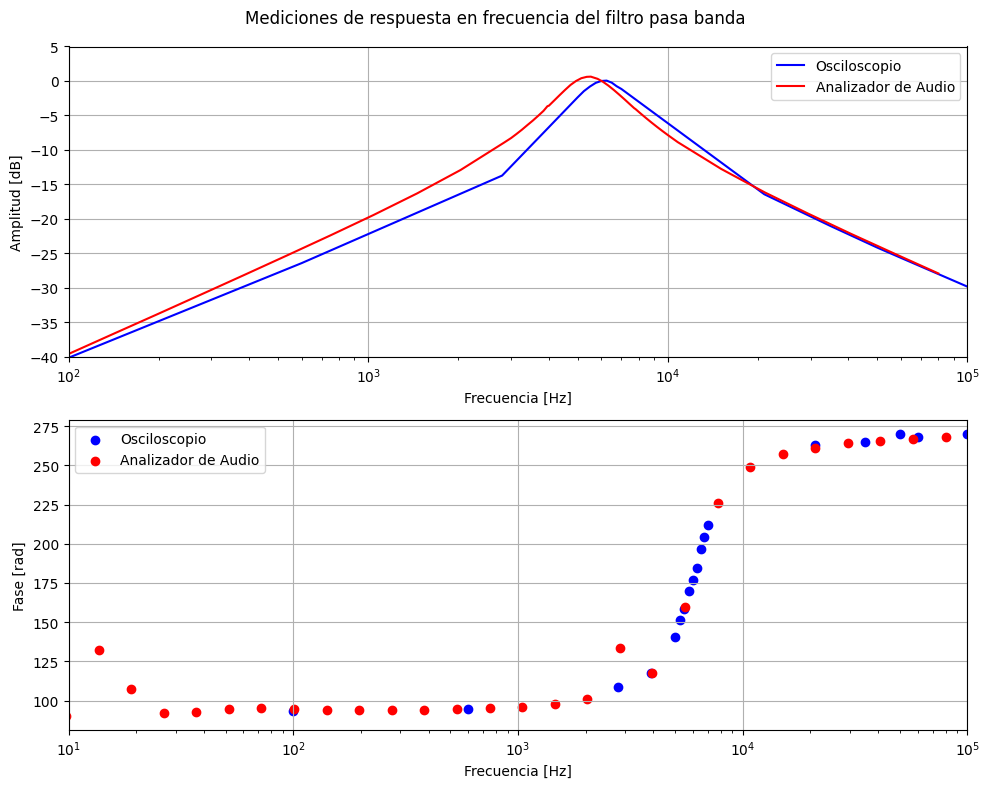

In [102]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 8))
plt.suptitle("Mediciones de respuesta en frecuencia del filtro pasa banda")

plt.subplot(211)
plt.semilogx(osc.iloc[:, 0], osc.iloc[:, 5], 'b', label='Osciloscopio')
plt.semilogx(aud.iloc[:, 0], aud.iloc[:, 1], 'r', label='Analizador de Audio')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.xlim(100,100000)
plt.legend()
plt.ylim(-40, 5)

plt.subplot(212)
plt.scatter(osc.iloc[:, 0], osc.iloc[:, 6], c='b', label='Osciloscopio')
plt.scatter(aud.iloc[:, 0], aud.iloc[:, 2], c='r', label='Analizador de Audio')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid(True)
plt.xlim(10,100000)
plt.xscale('log')
plt.legend()
#plt.ylim(-100, 5)

plt.tight_layout()
plt.show()

##### Simulaciones

Se realizaron simulaciones para poder determinar las diferencias entre el comportamiento ideal del circuito con el medido en el laboratorio. Para estas, se utilizó el mismo conjunto de frecuencias que utilizó el analizador de audio.

Se utilizaron los módulos _scipy.signal_ para simular la transferencia ideal del filtro:

In [78]:
Q=2.646
w0=2*np.pi*6000
k=-Q**2

b = [0,k*(w0/Q),0]
a = [1,w0/Q,w0**2]
w_set = aud.iloc[:, 0]*2*np.pi

w,h = sp.freqs(b,a,w_set)
w_hz = w/(2*np.pi)
h_db = 20*np.log10(np.abs(h))
h_ph = np.unwrap(np.angle(h))*(360/(2*np.pi))

Ayudandose del modelo de SPICE del amplificador operacional NE5534 brindado por el fabricante, también se simuló en LTSpice el circuito con los valores de resistores y capacitores utilizados a la hora de la medición:

<figure>
    <img src="fig/sim_circ.png" width="700"/>
    <figcaption align="center"><b>Figura 5:</b> Circuito en LTSpice</figcaption>
</figure>


A continuacion los resultados de ambas simulaciones:

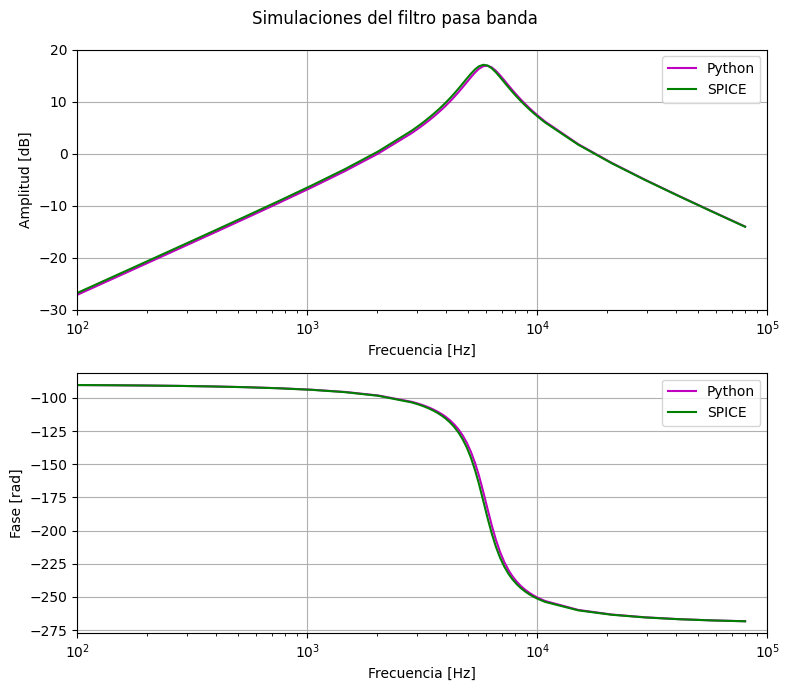

In [100]:
spice = pd.read_csv('sim/spice_res.csv')


plt.figure(figsize=(8, 7))
plt.suptitle("Simulaciones del filtro pasa banda")

plt.subplot(211)
plt.semilogx(w_hz, h_db, 'm', label='Python')
plt.semilogx(spice.iloc[:, 0], spice.iloc[:, 1], 'g', label='SPICE')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.xlim(100,100000)
plt.legend()
plt.ylim(-30, 20)

plt.subplot(212)
plt.semilogx(w_hz, h_ph, 'm', label='Python')
plt.semilogx(spice.iloc[:, 0], np.unwrap(spice.iloc[:, 2], period=360), 'g', label='SPICE')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid(True)
plt.xlim(100,100000)
plt.xscale('log')
plt.legend()
#plt.ylim(-100, 5)

plt.tight_layout()
plt.show()

Una comparación entre los resultados de las mediciones y los de la simulación de SPICE:

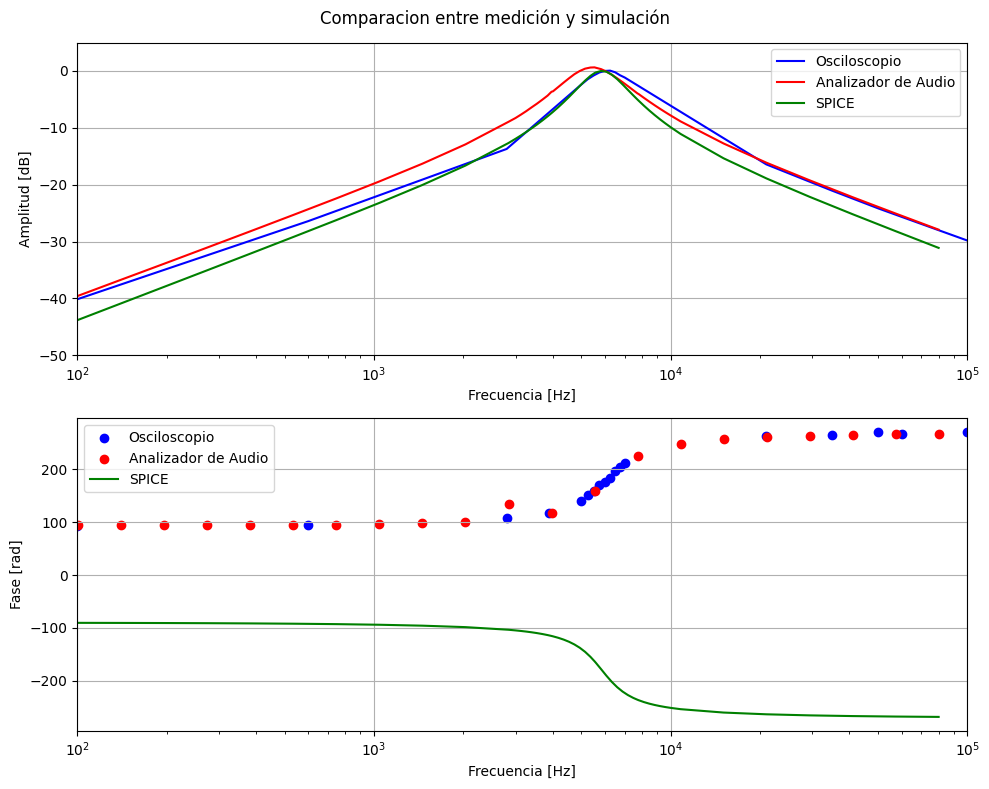

In [94]:
spice_rel = spice.iloc[:, 1] - max(spice.iloc[:, 1])

plt.figure(figsize=(10, 8))
plt.suptitle("Comparacion entre medición y simulación")

plt.subplot(211)
plt.semilogx(osc.iloc[:, 0], osc.iloc[:, 5], 'b', label='Osciloscopio')
plt.semilogx(aud.iloc[:, 0], aud.iloc[:, 1], 'r', label='Analizador de Audio')
plt.semilogx(spice.iloc[:, 0], spice_rel, 'g', label='SPICE')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.xlim(100,100000)
plt.legend()
plt.ylim(-50, 5)

plt.subplot(212)
plt.scatter(osc.iloc[:, 0], osc.iloc[:, 6], c='b', label='Osciloscopio')
plt.scatter(aud.iloc[:, 0], aud.iloc[:, 2], c='r', label='Analizador de Audio')
plt.plot(spice.iloc[:, 0], np.unwrap(spice.iloc[:, 2], period=360), 'g', label='SPICE')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid(True)
plt.xlim(100,100000)
plt.xscale('log')
plt.legend()

plt.tight_layout()
plt.show()

#### Conclusiones

Las diferencias entre las mediciones realizadas con el osciloscopio, mas artesanales, y con el analizador de audio, radican principalmente en una diferencia de aproximadamente 500 Hz entre la frecuencia central de una y otra, observable en la respuesta de módulo. Con el osciloscopio se llegó a que era cercana a la diseñada, 6 KHz, y con el analizador de audio resulto cercana a 5,5 KHz. Dado que el analizador de audio es un instrumento automático y de mayor precisión, es probable que la diferencia fuera causada por errores en la medición con osciloscopio. Las respuestas de fase medidas con ambos instrumentos resultaron ser similares, sin ninguna diferencia observable entre una y otra mas allá de dos desviaciones, cercanas a los 14 Hz y 3 KHz, en la medición con analizador de audio. La primera se puede deber a alguna frecuencia de resonancia del circuito causada por alguna reactancia parásita, pero la segunda es probable que haya sido un error del instrumento que otra cosa, ya que se desvía incluso de los valores contiguos de su misma medición.

Los resultados de las simulaciones fueron muy similares, con una diferencia minima en la frecuencia central entre estas, que puede deberse al uso del modelo de SPICE del amplificador operacional, el cual incluye algunas características del comportamiento real de este.

Al comparar las mediciones con la simulación en SPICE, se puede observar que la mayor diferencia ocurre fuera de la banda de paso. En la simulación, se logra una transición entre banda de paso a banda de rechazo mas abrupta, dando una diferencia de entre 3 y 4 dB entre la atenuación de una y otra. Esto se puede deber al problema que ya se mencionó de la impedancia de entrada del ciruito, la cual termino siendo 10 veces menor a la diseñada en un primer momento debido a que se tuvieron que improvisar nuevos valores por problemas en la compra de componentes. Esto se puede observar en que los valores de tensión de entrada del circuito siempre fueron menores a los 2 Vpp configurados en el generador, e incluso en valores de frecuencia altos se llegó a casi la mitad de esta tensión. Los filtros se diseñan para maximizar la transferencia de tensión, para lo cual se necesita que la impedancia de entrada del filtro sea al menos 10 veces mayor a la impedancia de salida de la señal. Al tener niveles de impendancia comparables, se pasa a una configuración de mayor transferencia de potencia, lo cual aumenta considerablemente la corriente que se transmite al filtro, generando caídas de tensión mayores. Se debería rearmar el circuito, esta vez con el nivel de impedancia inicialmente propuesto, y rehacer las mediciones para poder determinar si esa es la razón.

Es interesante también que se observa que en la banda de paso y en las frecuencias inferiores a esta el comportamiento de la simulación se asemeja mas a lo medido con el osciloscopio a lo medido con el analizador de audio. Al ser este ultimo un instrumento automático, puede que la baja impedancia de entrada del filtro haya infuido más en el resultado que con las mediciones mas artesanales realizadas con osciloscopio.